# Desarrollo MLP con encoder de dos etapas

Esta sensibilidad cambia sólo el encoder `6144→32` por `6144→64→32`. Predictor, datos, seeds, optimización y gates son idénticos al MLP de una capa anterior. Usa train/validation y no construye test.

In [1]:
# ruff: noqa: E402, E501
import json
import random
import sys
import time
from dataclasses import asdict, replace
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display

from koopman_jepa.paper_config import (
    PaperCheckpointReplayConfig,
    load_paper_mlp_one_hidden_development_config,
)
from koopman_jepa.paper_data import PAPER_REGIME_NAMES, PaperRegimeDataset, generate_paper_master
from koopman_jepa.paper_evaluation import (
    evaluate_paper_mlp_clustering_gate,
    evaluate_paper_mlp_seed_clustering,
)
from koopman_jepa.paper_model import PaperTemporalJEPA
from koopman_jepa.paper_training import (
    evaluate_scale_invariant_seed_stability_gate,
    make_paper_loader,
    run_paper_train_validation_with_checkpoint,
    summarize_seed_checkpoint,
    verify_paper_checkpoint_replay,
)

plt.style.use("seaborn-v0_8-whitegrid")
torch.use_deterministic_algorithms(True)

In [2]:
config = load_paper_mlp_one_hidden_development_config(
    ROOT / "configs" / "paper_mlp_two_stage_one_hidden_development.yaml"
)
replay_config = PaperCheckpointReplayConfig(metric_absolute_tolerance=1e-8)
train_dataset = PaperRegimeDataset(config.data, "train", generate_paper_master)
validation_dataset = PaperRegimeDataset(config.data, "val", generate_paper_master)
assert config.model.encoder_projection == "two_stage"
assert config.model.mlp_depth == "one_hidden"
assert len(train_dataset) == 64 * len(PAPER_REGIME_NAMES) == 1152
assert len(validation_dataset) == 32 * len(PAPER_REGIME_NAMES) == 576
assert {train_dataset.sample_key(i) for i in range(len(train_dataset))}.isdisjoint(
    {validation_dataset.sample_key(i) for i in range(len(validation_dataset))}
)
print(json.dumps(asdict(config), indent=2))
print("Test no fue instanciado.")

{
  "data": {
    "master_length": 1024,
    "context_length": 768,
    "shift": 256,
    "train_per_regime": 64,
    "val_per_regime": 32,
    "test_per_regime": 64,
    "base_seed": 1,
    "normalization": "per_sequence"
  },
  "model": {
    "latent_dim": 32,
    "input_length": 768,
    "encoder_projection": "two_stage",
    "predictor_kind": "mlp",
    "linear_initialization": "identity",
    "mlp_depth": "one_hidden",
    "ema_decay": 0.996
  },
  "train": {
    "optimizer": "adamw",
    "learning_rate": 0.0003,
    "weight_decay": 0.0,
    "batch_size": 64,
    "epochs": 20,
    "seed": 10,
    "device": "cpu",
    "num_workers": 0
  },
  "checkpoint_gate": {
    "final_window": 2,
    "max_validation_loss_ratio": 0.5,
    "max_validation_train_loss_ratio": 4.0,
    "min_validation_embedding_std_ratio": 0.1,
    "min_validation_effective_rank": 4.0
  },
  "sweep": {
    "seeds": [
      10,
      11,
      12,
      13,
      14
    ]
  },
  "stability_gate": {
    "max_worst_va

In [3]:
models, histories, summaries, replays, times = {}, {}, [], {}, {}
for seed in config.sweep.seeds:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    run_config = replace(config.train, seed=seed)
    model = PaperTemporalJEPA(config.model)
    started = time.perf_counter()
    run = run_paper_train_validation_with_checkpoint(
        model, train_dataset, validation_dataset, run_config, config.checkpoint_gate
    )
    histories[seed] = run.history
    times[seed] = time.perf_counter() - started
    if run.selection is None:
        best = min(run.history[1:], key=lambda row: row.validation_loss)
        print(f"seed={seed} NONE best_epoch={best.epoch} best_rank={best.validation_effective_rank:.2f}")
        continue
    replay = verify_paper_checkpoint_replay(
        model, run, validation_dataset, run_config, replay_config, expected_epoch=run.selection.epoch
    )
    models[seed], replays[seed] = model, replay
    summaries.append(summarize_seed_checkpoint(seed, run.selection))
    print(
        f"seed={seed} epoch={run.selection.epoch} val/base={run.selection.validation_loss_ratio:.3f} "
        f"gap={run.selection.validation_train_loss_ratio:.3f} rank={run.selection.validation_effective_rank:.2f} "
        f"replay={'PASS' if replay.passed else 'FAIL'}"
    )
replay_passed = set(replays) == set(config.sweep.seeds) and all(row.passed for row in replays.values())
predictive_gate = evaluate_scale_invariant_seed_stability_gate(summaries, config.sweep, config.stability_gate)
predictive_passed = replay_passed and predictive_gate.passed
print(f"Predictivo: {'PASS' if predictive_passed else 'FAIL'}; tiempo={sum(times.values()):.1f}s")
print(json.dumps(asdict(predictive_gate), indent=2))

seed=10 epoch=4 val/base=0.004 gap=1.022 rank=4.53 replay=PASS


seed=11 NONE best_epoch=7 best_rank=1.22


seed=12 NONE best_epoch=8 best_rank=2.91


seed=13 NONE best_epoch=7 best_rank=1.48


seed=14 NONE best_epoch=7 best_rank=1.89
Predictivo: FAIL; tiempo=203.5s
{
  "all_checkpoints_selected": false,
  "all_finite": true,
  "mean_validation_loss_ratio": 0.0035636529587031863,
  "validation_loss_ratio_coefficient_of_variation": 0.0,
  "absolute_validation_loss_coefficient_of_variation": 0.0,
  "worst_validation_loss_ratio": 0.0035636529587031863,
  "worst_validation_train_loss_ratio": 1.0219289981526818,
  "worst_validation_embedding_std_ratio": 1.173859261980882,
  "worst_validation_effective_rank": 4.528407573699951,
  "validation_loss_passed": true,
  "generalization_gap_passed": true,
  "variability_passed": true,
  "spread_passed": true,
  "rank_passed": true,
  "passed": false
}


In [4]:
@torch.no_grad()
def collect_embeddings(model, run_config):
    device = torch.device(run_config.device)
    model.to(device).eval()
    embeddings, labels = [], []
    for context, _, batch_labels in make_paper_loader(validation_dataset, run_config, shuffle=False):
        embeddings.append(model.online_encoder(context.to(device)).cpu().numpy())
        labels.append(batch_labels.numpy())
    return np.concatenate(embeddings), np.concatenate(labels)

clustering_metrics, clustering_gate = [], None
if predictive_passed:
    reference_labels = None
    for seed in config.sweep.seeds:
        embeddings, labels = collect_embeddings(models[seed], replace(config.train, seed=seed))
        reference_labels = labels if reference_labels is None else reference_labels
        assert np.array_equal(labels, reference_labels)
        clustering_metrics.append(
            evaluate_paper_mlp_seed_clustering(embeddings, labels, seed, config.clustering)
        )
    clustering_gate = evaluate_paper_mlp_clustering_gate(
        clustering_metrics, config.sweep, config.clustering_gate
    )
    print(json.dumps(asdict(clustering_gate), indent=2))
else:
    print("Clustering omitido: falló el prerrequisito predictivo.")
development_passed = predictive_passed and clustering_gate is not None and clustering_gate.passed
print(f"Resultado conjunto: {'PASS' if development_passed else 'FAIL'}")
print("Test no fue construido ni consultado.")

Clustering omitido: falló el prerrequisito predictivo.
Resultado conjunto: FAIL
Test no fue construido ni consultado.


seed epoch val/base rank purity_mean purity_sd
  10     4    0.004  4.53     not-run   not-run
  11  NONE
  12  NONE
  13  NONE
  14  NONE


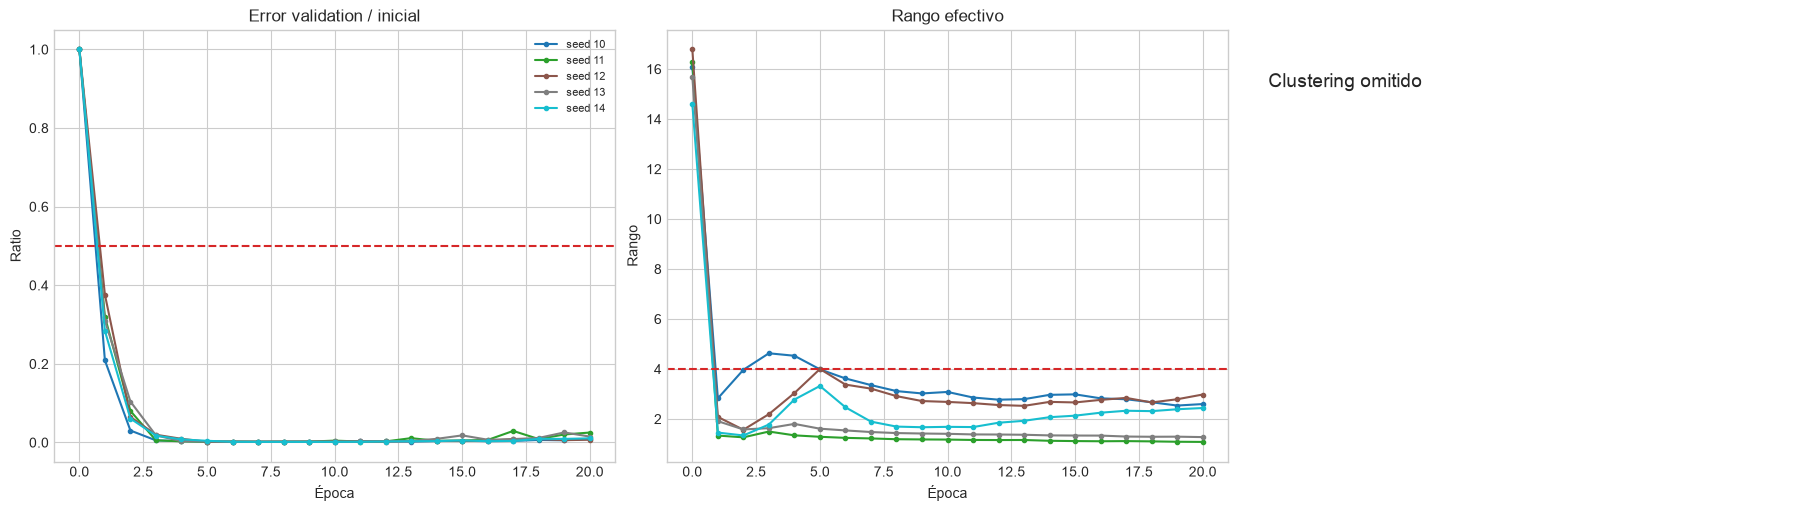

## Veredicto

- **Predictivo:** FAIL.
- **Clustering:** No medido porque no pasaron las cinco seeds.
- **Conjunto:** FAIL.

Test no fue construido ni consultado.


In [5]:
summary_by_seed = {row.seed: row for row in summaries}
cluster_by_seed = {row.seed: row for row in clustering_metrics}
print("seed epoch val/base rank purity_mean purity_sd")
for seed in config.sweep.seeds:
    summary, cluster = summary_by_seed.get(seed), cluster_by_seed.get(seed)
    if summary is None:
        print(f"{seed:>4d}  NONE")
        continue
    purity = f"{cluster.mean_purity:.2%}" if cluster else "not-run"
    purity_sd = f"{cluster.purity_std:.2%}" if cluster else "not-run"
    print(
        f"{seed:>4d} {summary.checkpoint_epoch:>5d} {summary.validation_loss_ratio:>8.3f} "
        f"{summary.validation_effective_rank:>5.2f} {purity:>11s} {purity_sd:>9s}"
    )

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
colors = plt.cm.tab10(np.linspace(0, 1, len(config.sweep.seeds)))
for color, seed in zip(colors, config.sweep.seeds, strict=True):
    history = histories[seed]
    epochs = np.array([row.epoch for row in history])
    losses = np.array([row.validation_loss for row in history])
    ranks = np.array([row.validation_effective_rank for row in history])
    axes[0].plot(epochs, losses / losses[0], marker="o", markersize=3, color=color, label=f"seed {seed}")
    axes[1].plot(epochs, ranks, marker="o", markersize=3, color=color)
axes[0].axhline(config.checkpoint_gate.max_validation_loss_ratio, color="tab:red", linestyle="--")
axes[0].set(title="Error validation / inicial", xlabel="Época", ylabel="Ratio")
axes[0].legend(fontsize=8)
axes[1].axhline(config.checkpoint_gate.min_validation_effective_rank, color="tab:red", linestyle="--")
axes[1].set(title="Rango efectivo", xlabel="Época", ylabel="Rango")
if clustering_gate is not None:
    seeds = np.array(config.sweep.seeds)
    means = np.array([cluster_by_seed[seed].mean_purity for seed in seeds])
    stds = np.array([cluster_by_seed[seed].purity_std for seed in seeds])
    axes[2].errorbar(seeds, means, yerr=stds, fmt="o", capsize=5)
    axes[2].axhline(config.clustering_gate.min_worst_seed_mean_purity, color="tab:red", linestyle="--")
    axes[2].axhline(0.6548, color="tab:green", linestyle=":")
    axes[2].set(title="Pureza media ± sd", xlabel="Seed", ylabel="Pureza")
else:
    axes[2].axis("off")
    axes[2].text(0.05, 0.9, "Clustering omitido", va="top", fontsize=14)
plt.show()

if clustering_gate is None:
    clustering_text = "No medido porque no pasaron las cinco seeds."
else:
    clustering_text = (
        f"Pureza global `{clustering_gate.overall_mean_purity:.2%}`; "
        f"peor seed `{clustering_gate.worst_seed_mean_purity:.2%}`."
    )
display(Markdown(f"""## Veredicto

- **Predictivo:** {'PASS' if predictive_passed else 'FAIL'}.
- **Clustering:** {clustering_text}
- **Conjunto:** {'PASS' if development_passed else 'FAIL'}.

Test no fue construido ni consultado.
"""))

## Análisis posterior a la corrida

El encoder de dos etapas empeora el prerrequisito predictivo de forma marcada. Sólo seed 10 selecciona un checkpoint formal (época 4, rango efectivo `4.53`). Las mejores épocas por error de seeds 11–14 tienen rangos `1.22`, `2.91`, `1.48` y `1.89`, todos por debajo del mínimo local `4.0`.

La seed aceptada reduce el error de validation a `0.004` del valor inicial y mantiene una brecha validation/train de `1.022`; el problema vuelve a ser la dimensionalidad de la representación, no la capacidad predictiva. Frente al encoder directo, que produjo cuatro de cinco checkpoints con el mismo predictor, la capa intermedia favorece soluciones aún más concentradas.

K-means fue omitido porque medir sólo seed 10 sería engañoso. Este resultado formal es **FAIL** y test no fue consultado. Para cerrar la sensibilidad, el siguiente diagnóstico seleccionará el mínimo error de las cinco seeds sin usar rango como filtro y medirá pureza únicamente en validation; será descriptivo y no alterará este veredicto.